# Análisis temporal de la relación entre temperatura e irradiancia solar

La temperatura y la irradiancia solar son variables fundamentales en el estudio del comportamiento del cambio climático. Estas variables presentan una relación directa por diversos factores físicos y temporales.

En este análisis se estudia la temperatura e irradiancia solar de Khulna (Ciudad en Bangladés) a lo largo del tiempo, así mismo como identificar patrones, desfases o posibles inconsistencias en su comportamiento.

**Objetivo**: Analizar la relación entre la irradiancia solar y la temperatura en función del tiempo, identificando patrones diarios y mensuales, así como posibles desfases térmicos o las variaciones en dicha relación.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Descripción del dataset
El conjunto de datos con el que se trabajará es "Solar Data Khulna". Contiene datos de temperatura (en grados Celsius) e irradiancia solar (en unidades de Watts por metro cuadrado) del año 2014 al año 2022.

El conjunto de datos contiene las siguientes columnas: Year, Month, Day, Hour (formato de 24 horas), Temperature, Irradiance.

## Carga y validación de datos

In [3]:
df = pd.read_csv("solar_data_khulna.csv")
df.head(10)

,Year,Month,Day,Hour,Temperature,Irradiance
0,2014,1,1,6,9.44,0.00
1,2014,1,1,7,11.87,99.09
2,2014,1,1,8,14.55,290.91
3,2014,1,1,9,17.81,492.71
4,2014,1,1,10,21.96,647.74
5,2014,1,1,11,23.67,681.32
6,2014,1,1,12,24.53,689.62
7,2014,1,1,13,24.94,633.41
8,2014,1,1,14,24.90,500.16
9,2014,1,1,15,24.09,317.09


In [4]:
df.shape

(78138, 6)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 78138 entries, 0 to 78137
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Year         78138 non-null  int64  
 1   Month        78138 non-null  int64  
 2   Day          78138 non-null  int64  
 3   Hour         78138 non-null  int64  
 4   Temperature  78138 non-null  float64
 5   Irradiance   78138 non-null  float64
dtypes: float64(2), int64(4)
memory usage: 3.6 MB


In [6]:
df.dtypes

Year             int64
Month            int64
Day              int64
Hour             int64
Temperature    float64
Irradiance     float64
dtype: object

In [7]:
df.describe()

,Year,Month,Day,Hour,Temperature,Irradiance
count,78138.000000,78138.000000,78138.000000,78138.000000,78138.000000,78138.000000
mean,2017.962221,6.471550,15.727175,11.500691,25.811352,187.138898
std,2.564001,3.422951,8.797685,6.922031,5.974301,255.156976
min,2014.000000,1.000000,1.000000,0.000000,5.420000,0.000000
25%,2016.000000,4.000000,8.000000,6.000000,22.730000,0.000000
50%,2018.000000,6.000000,16.000000,12.000000,26.660000,10.145000
75%,2020.000000,9.000000,23.000000,18.000000,29.460000,365.695000
max,2022.000000,12.000000,31.000000,23.000000,44.610000,969.310000


### Valores faltantes
Se verifica si tiene valores nulos con el objetivo de mejorar el analisis de las variables, en dado caso, se analiza si es conveniente reemplazarlos por valores como la media, el promedio, la moda, o eliminar estos valores sin perder el sentido y la relación con el objetivo.

In [8]:
df.isna().sum()

Year           0
Month          0
Day            0
Hour           0
Temperature    0
Irradiance     0
dtype: int64

### valor cero
Se verifica cuantos valores cero hay en cada columna para conocer si existe algún comportamiento inconsistente, por ejemplo, si llegará a existe un valor cero en irradiancia en alguna hora del medio dia, esto podria ser explicado por variables que desconocemos y no esten en el dataset, como humedad, lluvias, etc.

In [9]:
(df == 0).sum()

Year               0
Month              0
Day                0
Hour            3255
Temperature        0
Irradiance     37506
dtype: int64

In [12]:
df[df["Irradiance"] == 0].head(13)

,Year,Month,Day,Hour,Temperature,Irradiance
0,2014,1,1,6,9.44,0.0
12,2014,1,1,18,16.63,0.0
13,2014,1,1,19,15.82,0.0
14,2014,1,1,20,15.15,0.0
15,2014,1,1,21,14.62,0.0
16,2014,1,1,22,14.14,0.0
17,2014,1,1,23,13.69,0.0
18,2014,1,2,0,13.27,0.0
19,2014,1,2,1,12.91,0.0
20,2014,1,2,2,12.58,0.0


Los valores cero en irradiancia corresponden a horas nocturnas (0–6 y 18–23), lo cual es consistente físicamente y no representa datos faltantes.

## Correlación

<Axes: >

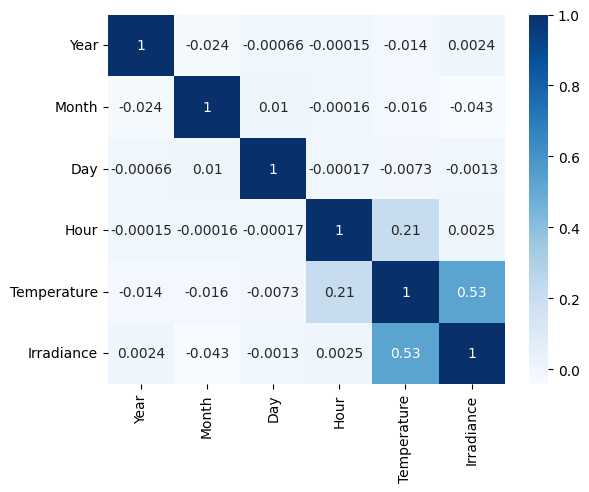

In [13]:
sns.heatmap(df.corr(), cmap="Blues", annot=True)

Se obtuvo una correlación moderada (0.53) entre irradiancia y temperatura, esto sugiere una relación positiva, sin embargo, no significa que sea estrictamente lineal. Esta correlación se puede ver afectadada por factores físicos como la humedad, un desfase térmico y variables que no se incluyen en el dataset.

## Análisis gráfco del comportamiento de Temperatura e irradiación por hora
Para analizar el comportamiento diario de la temperatura y la irradiancia, se calcula el promedio de ambas variables por hora.

In [25]:
df_hr = df.groupby("Hour")[["Temperature","Irradiance"]].mean().reset_index()
df_hr.head()

,Hour,Temperature,Irradiance
0,0,22.938885,0.0
1,1,22.571853,0.0
2,2,22.238046,0.0
3,3,21.932335,0.0
4,4,21.648829,0.0


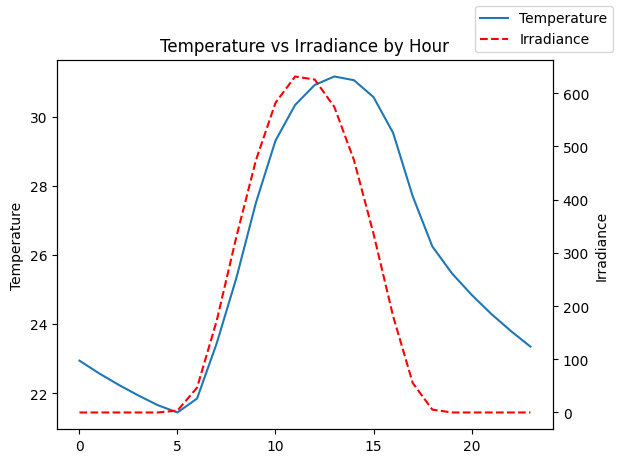

In [75]:
fig, ax1 = plt.subplots()

ax1.plot(df_hr["Hour"], df_hr["Temperature"], label="Temperature")
ax1.set_ylabel("Temperature")

ax2 = ax1.twinx()
ax2.plot(df_hr["Hour"], df_hr["Irradiance"], color = 'r', linestyle="--", label="Irradiance")
ax2.set_ylabel("Irradiance")

plt.title("Temperature vs Irradiance by Hour")

fig.legend()
plt.show()

Se puede observar que ambas variables presentan un comportamiento similar, sin embargo, la temperatura alcanza su máximo aproximadamente 2 a 3 horas despues que la irradiancia solar, esto podria deberse a un factor de desfase térmico.

## Análisis gráfco del comportamiento de Temperatura e irradiación por mes

In [28]:
df_month = df.groupby("Month")[["Temperature","Irradiance"]].mean().reset_index()
df_month.head()

,Month,Temperature,Irradiance
0,1,17.720873,157.783918
1,2,22.006949,187.687641
2,3,27.164210,222.049766
3,4,30.878302,233.343863
4,5,30.208277,227.563820


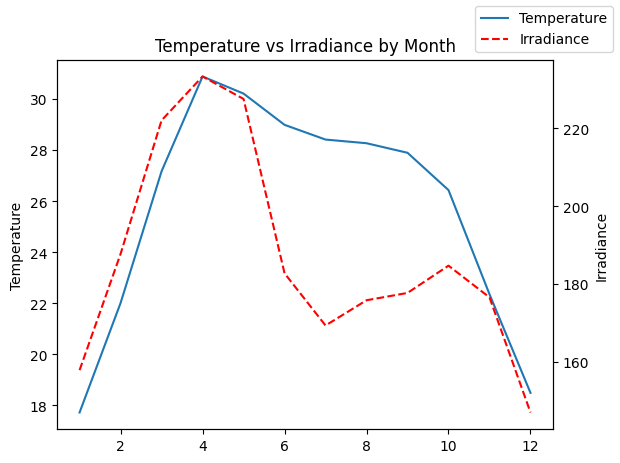

In [ ]:
fig, ax3 = plt.subplots()

ax3.plot(df_month["Month"], df_month["Temperature"], label="Temperature")
ax3.set_ylabel("Temperature")

ax4 = ax3.twinx()
ax4.plot(df_month["Month"], df_month["Irradiance"], color = 'r', linestyle="--", label="Irradiance")
ax4.set_ylabel("Irradiance")

plt.title("Temperature vs Irradiance by Month")

fig.legend()
plt.show()

A diferencia del comportamiento por hora, la relación entre temperatura e irradiancia varia significativamente a lo largo de los meses, y con el objetivo de analizar si la relación temporal entre temperatura e irradiancia cambia a lo largo del año, se comparó el comportamiento horario promedio de ambas variables en los meses de abril y julio.

In [69]:
df_abril = df[df["Month"] == 4]

In [66]:
df_abril_hr = df_abril.groupby("Hour")[["Temperature", "Irradiance"]].mean().reset_index()
df_abril_hr.head()

,Hour,Temperature,Irradiance
0,0,26.288333,0.0
1,1,25.809926,0.0
2,2,25.402667,0.0
3,3,25.059593,0.0
4,4,24.760481,0.0


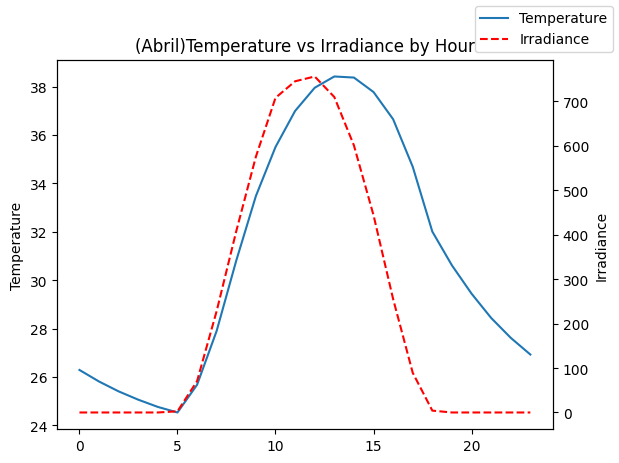

In [ ]:
fig, ax5 = plt.subplots()

ax5.plot(df_abril_hr["Hour"], df_abril_hr["Temperature"], label = "Temperature")
ax5.set_ylabel("Temperature")

ax6 = ax5.twinx()
ax6.plot(df_abril_hr["Hour"], df_abril_hr["Irradiance"], color = 'r', linestyle="--", label = "Irradiance")
ax6.set_ylabel("Irradiance")

plt.title("(Abril)Temperature vs Irradiance by Hour")

fig.legend()
plt.show()

In [72]:
dF_jul = df[df["Month"] == 7]

In [73]:
df_jul_hr = dF_jul.groupby("Hour")[["Temperature", "Irradiance"]].mean().reset_index()
df_jul_hr.head()

,Hour,Temperature,Irradiance
0,0,26.614373,0.0
1,1,26.494194,0.0
2,2,26.398530,0.0
3,3,26.314086,0.0
4,4,26.236022,0.0


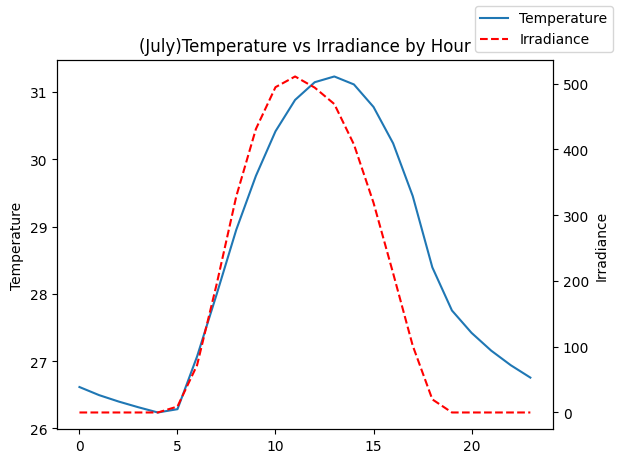

In [78]:
fig, ax7 = plt.subplots()

ax7.plot(df_jul_hr["Hour"], df_jul_hr["Temperature"], label="Temperature")
ax7.set_ylabel("Temperature")

ax8 = ax7.twinx()
ax8.plot(df_jul_hr["Hour"], df_jul_hr["Irradiance"], color = 'r', linestyle="--", label="Irradiance")
ax8.set_ylabel("Irradiance")

plt.title("(July)Temperature vs Irradiance by Hour")

fig.legend()
plt.show()

Aunque la relación entre temperatura e irradiancia presenta variaciones mensuales en su magnitud, el comportamiento horario mantiene una dinámica similar entre distintos meses, conservando el desfase térmico de 2 a 3 horas observado previamente.

En abril se observan valores máximos mayores tanto de irradiancia como de temperatura respecto a julio, lo que indica una diferencia significativa en intensidad entre ambos meses.

Por lo tanto, es por esto que, en el análisis gráfico del comportamiento de temperatura e irradiancia por mes, se observa un comportamiento inconsistente entre ambas variables en estos meses.

## Variabilidad de la irradiancia entre abril y julio
A continuación se compara la dispersión de los valores de irradiancia entre ambos meses.

In [83]:
df_box = df[df["Month"].isin([4, 7])]

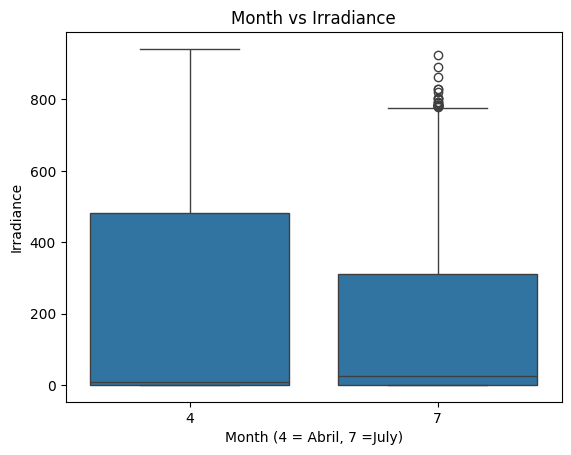

In [86]:
sns.boxplot(x = 'Month', y = 'Irradiance', data = df_box)
plt.title('Month vs Irradiance')
plt.xlabel('Month (4 = Abril, 7 =July)')
plt.ylabel('Irradiance')
plt.show()

Abril presenta valores de irradiancia más altos y una mayor variabilidad respecto a julio, lo que coincide con las diferencias de magnitud observadas previamente en el análisis horario.